In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import joblib
import pickle

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
!pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00


In [16]:
file_path = '/kaggle/input/datasets/mexwell/fake-reviews-dataset/fake reviews dataset.csv' 
df = pd.read_csv(file_path)

print(f"Jumlah review: {len(df):,}")
print(f"Jumlah kolom: {df.shape[1]}")
print()
print(f"Kolom yang tersedia:\n{list(df.columns)}")

Jumlah review: 40,432
Jumlah kolom: 4

Kolom yang tersedia:
['category', 'rating', 'label', 'text_']


In [17]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [19]:
df.dtypes

category     object
rating      float64
label        object
text_        object
dtype: object

In [20]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [21]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
category    0
rating      0
label       0
text_       0
dtype: int64


In [22]:
print("Distribusi Rating:")
print(df['rating'].value_counts().sort_index())

Distribusi Rating:
rating
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24559
Name: count, dtype: int64


In [23]:
print("Distribusi Label:")
print(df['label'].value_counts())

Distribusi Label:
label
CG    20216
OR    20216
Name: count, dtype: int64


In [24]:
print("Top 10 Category:")
print(df['category'].value_counts().head(10))

Top 10 Category:
category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: int64


In [27]:
import string
import re
import contractions
from nltk.tokenize import word_tokenize

# en_stopwords = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def preprocessing(statement):
    # 1. Lowercasing
    statement = statement.lower()
    # 2. Contraction handling (don't -> do not, can't -> cannot)
    statement = contractions.fix(statement)
    # 3. Hapus punctuation 
    statement = re.sub(r'[^\w\s]', '', statement)
    # 4. Hapus angka 
    statement = re.sub(r'\d+', '', statement)
    # 5. Tokenisasi
    tokens = word_tokenize(statement)
    # 6. Hanya huruf (hapus angka sisa)
    tokens = [token for token in tokens if token.isalpha()]
    # 7. Hapus kata yang terlalu pendek (1-2 karakter)
    tokens = [token for token in tokens if len(token) > 2]
    
    return ' '.join(tokens)

df['clean_text'] = df['text_'].apply(preprocessing)

print("Contoh hasil:")
print("\nOriginal:", df['text_'].iloc[0])
print("Clean:", df['clean_text'].iloc[0])

Contoh hasil:

Original: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
Clean: love this well made sturdy and very comfortable love itvery pretty


In [28]:
df['label'] = (df['label'] == 'CG').astype(int)

print("Distribusi Label setelah konversi:")
print(f"Asli (0): {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Palsu (1): {(df['label']==1).sum():,} ({(df['label']==1).mean()*100:.1f}%)")

Distribusi Label setelah konversi:
Asli (0): 20,216 (50.0%)
Palsu (1): 20,216 (50.0%)


In [52]:
print("Contoh Review Asli (Label=0):")
print(df[df['label']==0][['clean_text', 'rating']].head())
print()
print("Contoh Review Palsu (Label=1):")
print(df[df['label']==1][['clean_text', 'rating']].head())

Contoh Review Asli (Label=0):
                                           clean_text  rating
55  these are just perfect exactly what was lookin...     5.0
56     such great purchase can not beat for the price     5.0
57          what can you say cheap and works intended     5.0
58   these are nice sturdy like the color choices too     5.0
59               nice bowl and have had fast shipping     5.0

Contoh Review Palsu (Label=1):
                                          clean_text  rating
0  love this well made sturdy and very comfortabl...     5.0
1  love great upgrade from the original have had ...     5.0
2  this pillow saved back love the look and feel ...     5.0
3  missing information how use but great product ...     1.0
4  very nice set good quality have had the set fo...     5.0


In [30]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print(f"\nTrain - Asli: {sum(y_train==0):,}, Palsu: {sum(y_train==1):,}")
print(f"Test - Asli: {sum(y_test==0):,}, Palsu: {sum(y_test==1):,}")

Train size: 32,345
Test size: 8,087

Train - Asli: 16,172, Palsu: 16,173
Test - Asli: 4,044, Palsu: 4,043


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape X_train: {X_train_tfidf.shape}")
print(f"Shape X_test: {X_test_tfidf.shape}")

Shape X_train: (32345, 10000)
Shape X_test: (8087, 10000)


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)

print("Training Model Random Forest selesai")

y_pred_rf = rf.predict(X_test_tfidf)

print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Asli', 'Palsu']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Training Model Random Forest selesai
RANDOM FOREST
Accuracy: 0.8942
Precision: 0.9201
Recall: 0.8632
F1-Score: 0.8908

Classification Report:
              precision    recall  f1-score   support

        Asli       0.87      0.93      0.90      4044
       Palsu       0.92      0.86      0.89      4043

    accuracy                           0.89      8087
   macro avg       0.90      0.89      0.89      8087
weighted avg       0.90      0.89      0.89      8087


Confusion Matrix:
[[3741  303]
 [ 553 3490]]


In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

print("Training Model Logistic Regression selesai")

y_pred_lr = lr.predict(X_test_tfidf)

print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Asli', 'Palsu']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Training Model Logistic Regression selesai
LOGISTIC REGRESSION
Accuracy: 0.9273
Precision: 0.9331
Recall: 0.9206
F1-Score: 0.9268

Classification Report:
              precision    recall  f1-score   support

        Asli       0.92      0.93      0.93      4044
       Palsu       0.93      0.92      0.93      4043

    accuracy                           0.93      8087
   macro avg       0.93      0.93      0.93      8087
weighted avg       0.93      0.93      0.93      8087


Confusion Matrix:
[[3777  267]
 [ 321 3722]]


In [34]:
from xgboost import XGBClassifier

scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_tfidf, y_train)

print("Training Model XGBoost selesai")

y_pred_xgb = xgb.predict(X_test_tfidf)

print("XGBOOST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Asli', 'Palsu']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:23:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Model XGBoost selesai
XGBOOST
Accuracy: 0.8885
Precision: 0.9117
Recall: 0.8603
F1-Score: 0.8852

Classification Report:
              precision    recall  f1-score   support

        Asli       0.87      0.92      0.89      4044
       Palsu       0.91      0.86      0.89      4043

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087


Confusion Matrix:
[[3707  337]
 [ 565 3478]]


In [35]:
print("Perbandingan Model")
print("="*50)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"Random Forest       : Acc={rf_acc:.4f}, Prec={rf_prec:.4f}, Rec={rf_rec:.4f}, F1={rf_f1:.4f}")
print(f"Logistic Regression : Acc={lr_acc:.4f}, Prec={lr_prec:.4f}, Rec={lr_rec:.4f}, F1={lr_f1:.4f}")
print(f"XGBoost             : Acc={xgb_acc:.4f}, Prec={xgb_prec:.4f}, Rec={xgb_rec:.4f}, F1={xgb_f1:.4f}")

Perbandingan Model
Random Forest       : Acc=0.8942, Prec=0.9201, Rec=0.8632, F1=0.8908
Logistic Regression : Acc=0.9273, Prec=0.9331, Rec=0.9206, F1=0.9268
XGBoost             : Acc=0.8885, Prec=0.9117, Rec=0.8603, F1=0.8852


In [36]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [rf_acc, lr_acc, xgb_acc],
    'Precision': [rf_prec, lr_prec, xgb_prec],
    'Recall': [rf_rec, lr_rec, xgb_rec],
    'F1-Score': [rf_f1, lr_f1, xgb_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.894151   0.920116  0.863220  0.890761
1  Logistic Regression  0.927291   0.933066  0.920604  0.926793
2              XGBoost  0.888463   0.911664  0.860252  0.885213


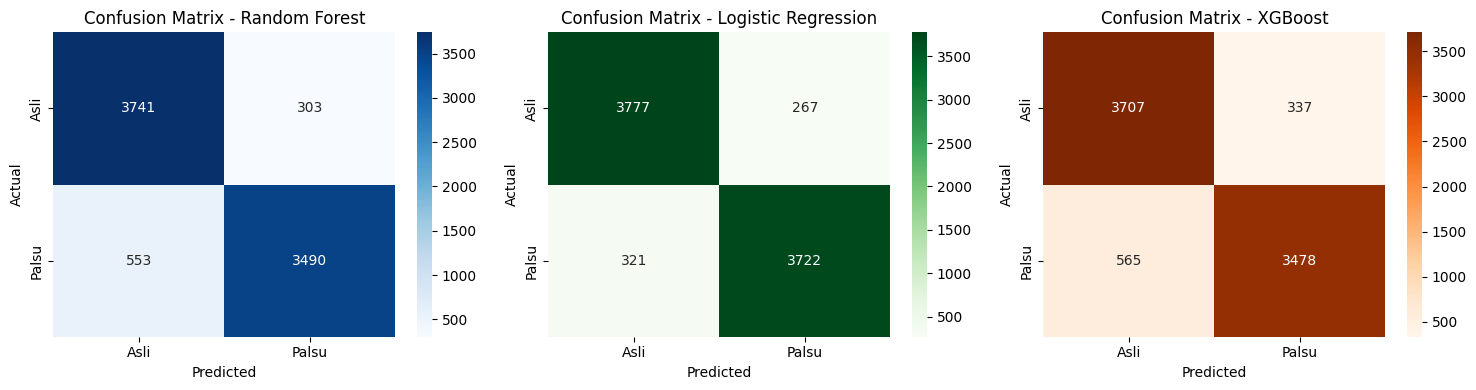

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 3, 2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 3, 3)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

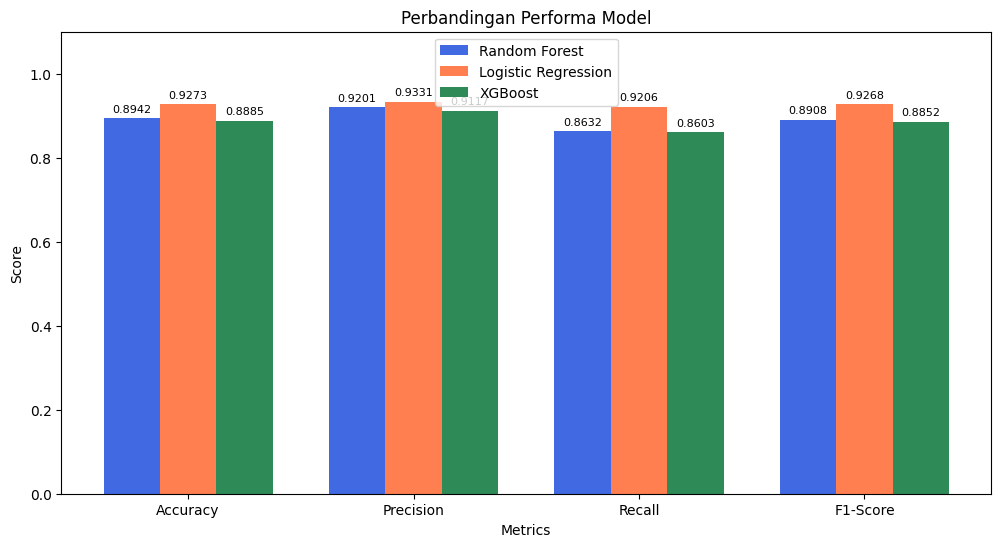

In [38]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
xgb_scores = [xgb_acc, xgb_prec, xgb_rec, xgb_f1]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))
bars1 = plt.bar([i - width for i in x], rf_scores, width, label='Random Forest', color='royalblue')
bars2 = plt.bar(x, lr_scores, width, label='Logistic Regression', color='coral')
bars3 = plt.bar([i + width for i in x], xgb_scores, width, label='XGBoost', color='seagreen')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Perbandingan Performa Model')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.show()

In [39]:
import joblib
import pickle

joblib.dump(rf, 'random_forest_model.pkl')
print("Random Forest disimpan sebagai 'random_forest_model.pkl'")

joblib.dump(lr, 'logistic_regression_model.pkl')
print("Logistic Regression disimpan sebagai 'logistic_regression_model.pkl'")

joblib.dump(xgb, 'xgboost_model.pkl')
print("XGBoost disimpan sebagai 'xgboost_model.pkl'")

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("TF-IDF Vectorizer disimpan sebagai 'tfidf_vectorizer.pkl'")

Random Forest disimpan sebagai 'random_forest_model.pkl'
Logistic Regression disimpan sebagai 'logistic_regression_model.pkl'
XGBoost disimpan sebagai 'xgboost_model.pkl'
TF-IDF Vectorizer disimpan sebagai 'tfidf_vectorizer.pkl'


# Deep learning menggunakan Word2Vec dan LSTM

In [40]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

2026-05-31 13:24:07.856460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780233848.070353      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780233848.133919      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780233848.645140      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233848.645166      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233848.645169      58 computation_placer.cc:177] computation placer alr

In [41]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Train pad shape: {X_train_pad.shape}")
print(f"Test pad shape: {X_test_pad.shape}")

Train pad shape: (32345, 100)
Test pad shape: (8087, 100)


In [42]:
from gensim.models import Word2Vec

sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=10)

print(f"Vocab size: {len(w2v_model.wv)}")

Vocab size: 21225


In [43]:
vocab_size = min(10000, len(tokenizer.word_index) + 1)
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]
        else:
            embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)

print(f"Embedding matrix: {embedding_matrix.shape}")

Embedding matrix: (10000, 100)


In [44]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1780233899.511343      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780233899.517239      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 183s 431ms/step - accuracy: 0.7876 - loss: 0.4269 - val_accuracy: 0.8930 - val_loss: 0.2580
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 175s 432ms/step - accuracy: 0.8989 - loss: 0.2438 - val_accuracy: 0.9136 - val_loss: 0.2059
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 173s 427ms/step - accuracy: 0.9199 - loss: 0.1989 - val_accuracy: 0.9229 - val_loss: 0.1919
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 174s 430ms/step - accuracy: 0.9318 - loss: 0.1714 - val_accuracy: 0.9270 - val_loss: 0.1778
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 173s 426ms/step - accuracy: 0.9419 - loss: 0.1473 - val_accuracy: 0.9298 - val_loss: 0.1783
Epoch 6/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 174s 430ms/step - accuracy: 0.9494 - loss: 0.1278 - val_accuracy: 0.9357 - val_loss: 0.1779
Epoch 7/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 175s 431ms/step - accuracy: 0.9578 - loss: 0.1125 - val_accuracy: 0.9371 - val_loss: 0.1756
Epoch 8/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 174s 430ms/step - accuracy: 0.9612 -

In [46]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype(int)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_prec = precision_score(y_test, y_pred_lstm)
lstm_rec = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("LSTM + Word2Vec")
print("="*50)
print(f"Accuracy: {lstm_acc:.4f}")
print(f"Precision: {lstm_prec:.4f}")
print(f"Recall: {lstm_rec:.4f}")
print(f"F1-Score: {lstm_f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lstm))

253/253 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step
LSTM + Word2Vec
Accuracy: 0.9371
Precision: 0.9455
Recall: 0.9275
F1-Score: 0.9364

Confusion Matrix:
[[3828  216]
 [ 293 3750]]


In [47]:
import json
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer disimpan sebagai 'tokenizer.pkl'")

model.save('lstm_word2vec_model.h5')
print("Model LSTM disimpan sebagai 'lstm_word2vec_model.h5'")

lstm_config = {
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim
}

with open('lstm_config.json', 'w') as f:
    json.dump(lstm_config, f, indent=4)
print("konfigurasi LSTM disimpan sebagai 'lstm_config.json'")

Tokenizer disimpan sebagai 'tokenizer.pkl'
Model LSTM disimpan sebagai 'lstm_word2vec_model.h5'
konfigurasi LSTM disimpan sebagai 'lstm_config.json'


# Comparison Semua Model

In [48]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost', 'LSTM + Word2Vec'],
    'Accuracy': [rf_acc, lr_acc, xgb_acc, lstm_acc],
    'Precision': [rf_prec, lr_prec, xgb_prec, lstm_prec],
    'Recall': [rf_rec, lr_rec, xgb_rec, lstm_rec],
    'F1-Score': [rf_f1, lr_f1, xgb_f1, lstm_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.894151   0.920116  0.863220  0.890761
1  Logistic Regression  0.927291   0.933066  0.920604  0.926793
2              XGBoost  0.888463   0.911664  0.860252  0.885213
3      LSTM + Word2Vec  0.937059   0.945537  0.927529  0.936446


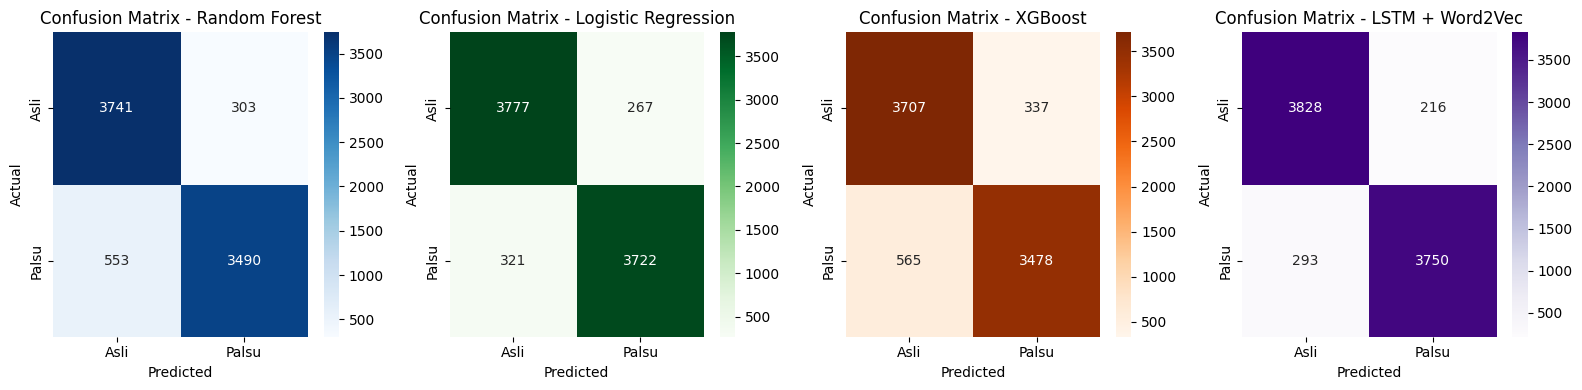

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 4, 2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 4, 3)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 4, 4)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Asli', 'Palsu'], 
            yticklabels=['Asli', 'Palsu'])
plt.title('Confusion Matrix - LSTM + Word2Vec')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

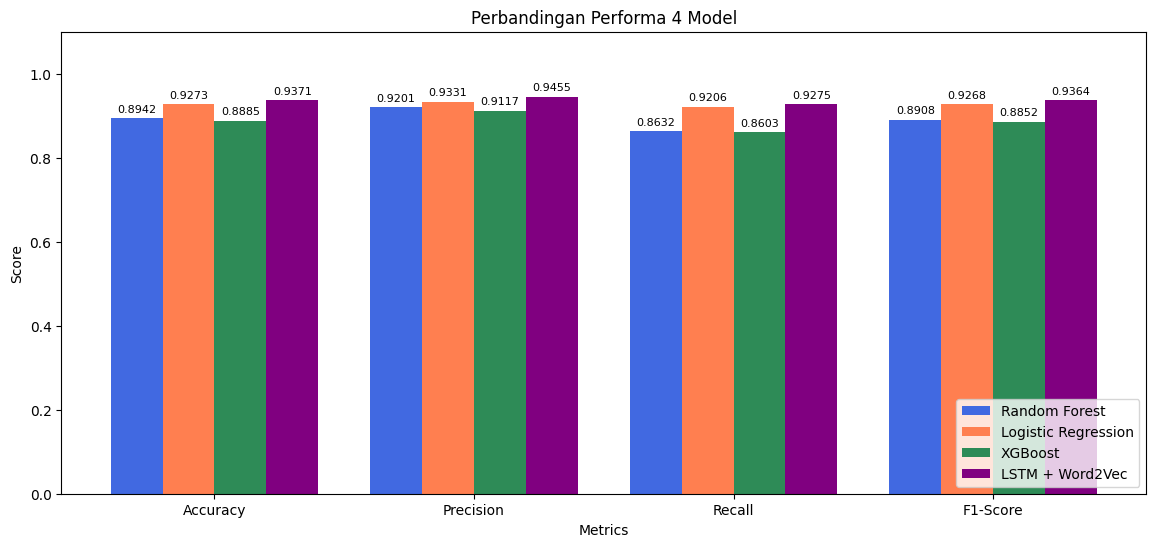

In [50]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
xgb_scores = [xgb_acc, xgb_prec, xgb_rec, xgb_f1]
lstm_scores = [lstm_acc, lstm_prec, lstm_rec, lstm_f1]

x = range(len(metrics))
width = 0.2

plt.figure(figsize=(14, 6))
bars1 = plt.bar([i - 1.5*width for i in x], rf_scores, width, label='Random Forest', color='royalblue')
bars2 = plt.bar([i - 0.5*width for i in x], lr_scores, width, label='Logistic Regression', color='coral')
bars3 = plt.bar([i + 0.5*width for i in x], xgb_scores, width, label='XGBoost', color='seagreen')
bars4 = plt.bar([i + 1.5*width for i in x], lstm_scores, width, label='LSTM + Word2Vec', color='purple')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars4:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Perbandingan Performa 4 Model')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

In [ ]:
import os
import shutil

os.makedirs('models/klasik', exist_ok=True)
os.makedirs('models/deep_learning', exist_ok=True)

In [56]:
klasik_files = [
    'best_model.pkl',
    'random_forest_model.pkl',
    'logistic_regression_model.pkl',
    'xgboost_model.pkl',
    'tfidf_vectorizer.pkl'
]

moved = 0
for file in klasik_files:
    if os.path.exists(file):
        shutil.move(file, f'models/klasik/{file}')
        print(f"Dipindahkan: {file} → models/klasik/")
        moved += 1
    else:
        print(f"File tidak ditemukan: {file}")

print(f"\n{moved} file klasik dipindahkan")

File tidak ditemukan: best_model.pkl
File tidak ditemukan: random_forest_model.pkl
File tidak ditemukan: logistic_regression_model.pkl
File tidak ditemukan: xgboost_model.pkl
File tidak ditemukan: tfidf_vectorizer.pkl

0 file klasik dipindahkan


In [55]:
dl_files = [
    'lstm_word2vec_model.h5',
    'tokenizer.pkl',
    'lstm_config.json'
]

moved = 0
for file in dl_files:
    if os.path.exists(file):
        shutil.move(file, f'models/deep_learning/{file}')
        print(f"Dipindahkan: {file} → models/deep_learning/")
        moved += 1
    else:
        print(f"File not found: {file}")

print(f"\n{moved} file deep learning dipindahkan")

✅ Dipindahkan: lstm_word2vec_model.h5 → models/deep_learning/
✅ Dipindahkan: tokenizer.pkl → models/deep_learning/
✅ Dipindahkan: lstm_config.json → models/deep_learning/

✅ 3 file deep learning dipindahkan
